[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

# Sea Ice Thickness in the Climate Data Store - Datasets, Changes & Trends

**This notebook can be run on free online platforms, such as Binder, Kaggle and Colab. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.**

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/jupyter-template/main?labpath=jupyter-notebook-template.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/jupyter-template/blob/main/jupyter-notebook-template.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/jupyter-template/blob/main/jupyter-notebook-template.ipynb)


## Learning objectives 🎯

In this tutorial, you will learn how to:

1. **Access**: Download the sea ice thickness climate data record (CDR) and the CryoSat-2/SMOS sea ice thickness data record from the Copernicus Climate Data Store (CDS) using the `cdsapi` Python library.
2. **Content**: Examine the structure of the dataset using `xarray` and understand the content and scope of the geophysical variables and supporting flag variables. 
3. **Different Data Records**: Understand the differences between the sea ice thickness climate data records and the combined CryoSat-2/SMOS dataset.
4. **Sea Ice Thickness Changes**: Compute and plot regional sea ice thickness trends and understand their limitiations.

## Prepare your environment

Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the Climate Data Store (CDS), setting up our CDS API credentials and importing the various Python packages that we will need.

The code below will install the CDS API. It is assumed the other required Python package, [xarray](https://xarray.dev/), is already installed, which would be the case if you are using the free online Jupyterlab environments (see links above).

#### Install CDS API

In [1]:
!pip install -q cdsapi

### Install Supporting Python Packages

In [2]:
!pip install -q cartopy scipy matplotlib colormaps

### Setup credentials (optional)

If you have not setup your `~/.cdsapirc` file with your credentials, you can replace `None` with your credentials that can be found on the [how to api](https://cds.climate.copernicus.eu/how-to-api) page (you will need to log in to see your credentials).

In [3]:
# If you have already setup your .cdsapirc file you can leave this as None
cdsapi_key = None
cdsapi_url = None

### Import libraries

We will be working with data in NetCDF format. To best handle this data, we will use the [Xarray](https://xarray.dev/) library for working with multidimensional arrays. In addition, [numpy](https://numpy.org/) will be used for numerical operations, [scipy](https://scipy.org/) for scientific computations, [matplotlib](https://matplotlib.org/) for plotting, and [cartopy](https://scitools.org.uk/cartopy/docs/latest/) for mapping.

For scientific colormaps, we recommend the [colormaps](https://pratiman-91.github.io/colormaps/) package, which provides a collection of perceptually uniform colormaps for scientific visualization.

In [4]:
# For accessing dataset on the Climate Data Store
import cdsapi

# For working with multidimensional arrays
import xarray as xr
import numpy as np
from scipy.stats import linregress

# Helper packages included in python distributions (batteries included)
import zipfile
from pathlib import Path
from typing import Literal

# For data plots and maps
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import colormaps as cmaps


## Sea Ice Thickness Datasets in the Climate Data Store

We will now search, download and explore sea ice thickness data records from the [Climate Data Store](https://cds.climate.copernicus.eu/). Two datasets with different source datasets and scope are available here: [Sea ice thickness gridded data for the Arctic derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-thickness).

1. Sea Ice Thickness Climate Data Record (SIT CDR, version 3)
2. CryoSat-2/SMOS Sea Ice Thickness Data Record (CS2SMOS SIT, version 1)


### Sea Ice Thickness Download Options

Having selected the [correct dataset](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-thickness), we now need to specify which processing level, satellite mission, variables, temporal coverage and version we are interested in. These can all be selected in the **"Download data"** tab. In this tab a form appears with several available options. 

```{note}
Note: Not all options are available for all datasets.
```

- **Processing Level**: The processing level defines the degree of processing applied to the data. Level-3 indicates that data from the satellite has been processed and gridded, while Level-4 indicates that the data has been further processed. In this case, the climate data record (CDR) is a Level-3 product, while the CryoSat-2/SMOS sea ice thickness data record is a Level-4 product due to the gap-filling and optimal interpolation applied to the data. (Choices: `Level-3` for the SIT CDR and `Level-4` for the combined CryoSat-2/SMOS data record.)
- **Satellite Mission**: The Envisat satellite mission was launched in 2002 and generated radar altimeter data until 2012, while the CryoSat-2 satellite mission was launched in 2010 and is still operational. The combined product is a combination of CryoSat-2 and SMOS satellite missions. (Choices: `Envisat, CryoSat-2, Combined Product`.)
- **Temporal Resolution**: The resolution is monthly for the climate data record, and daily for the combined CryoSat-2/SMOS product. (Choices: `Daily, Monthly`)
- **Variable**: Both data sets contain only `Sea Ice Thickness` as a geophysical variable.
- **Year**: The SIT CDR is available from 2002 to 2023, while the CS2SMOS SIT is available from 2010 to 2023.
- **Month**: Both sea ice thickness data records are only generated for the Arctic winter months (October to April).
- **Day**: A list of days within a month. This field can only be selected for the CryoSat-2/SMOS combined sea ice thickness data record.
- **Version**: A version string indicating the version of the dataset. Available versions depend on the selected dataset.

At the end of the download form, select **"Show API request"**. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook (see cell below). Having copied the API request into the cell below, running this will retrieve and download the data you requested into your local directory. However, before you run the cell below, the **terms and conditions** of this particular dataset need to have been accepted in the CDS. This needs to be done only once per dataset and per user. The option to view and accept these conditions is given at the end of the download form, just above the **"Show API request"** option.

:warning: Please remember to **accept the terms and conditions** of the dataset, at the bottom of the CDS download form!

With the API request copied into the cell below, running this cell will retrieve and download the data you requested into your local directory.

### Preparation before running the API request

Here we specify a data directory in which we will download our data and all output files that we will generate:

In [ ]:
DATADIR = './data_dir/'

### Download Sea Ice Thickness Climate Data Record

The following example API request will download the Sea Ice Thickness Climate Data Record (SIT CDR, version 3) for the Arctic winter months (October to April) from 2008 to 2023. The data will be downloaded as a collection of files in NetCDF format contained in a zip archive, which saved as `sea_ice_thickness_cdr_v3.zip` in the current working directory.

In [6]:
# Dataset request
dataset = "satellite-sea-ice-thickness"
request = {
    "processing_level": "level_3",
    "satellite_mission": ["envisat", "cryosat_2"],
    "variable": ["sea_ice_thickness"],
    "temporal_resolution": ["monthly"],
    "year": [f"{year}" for year in range(2008, 2025)],
    "month": [
        "01", "02", "03",
        "04", "10", "11",
        "12"
    ],
    "version": "3_0"
}

# Create a subdirectory for the Level-3 SIT CDR data
target_directory_l3 = Path(DATADIR) / "level_3_sit_cdr"
archive_path = target_directory_l3 / "sea_ice_thickness_cdr_v3.zip"

# --- DEBUGGING ---
# print(f"Save archive_path: {archive_path.absolute()}")

if not Path(target_directory_l3).exists():
    Path(target_directory_l3).mkdir(parents=True, exist_ok=True)

if not Path(archive_path).exists():
    # Initiate the download of the zip archive containing the SIT CDR data
    client = cdsapi.Client()
    client.retrieve(dataset, request).download(str(archive_path))

# Extract netCDF files from archive
with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(target_directory_l3)

### Download Combined Sea Ice Thickness CryoSat-2/SMOS Data Record

The following example API request will download the Combined Sea Ice Thickness Data Record (CryoSat-2/SMOS, version 1) for the Arctic winter months (October to April) since November 2010. The temporal resolution is daily.

The data will be downloaded as a collection of files in NetCDF format contained in a zip archive, which saved as `sea_ice_thickness_cs2smos_v1.zip` in the current working directory.

In [7]:
# Dataset request
dataset = "satellite-sea-ice-thickness"
request = {
    "processing_level": "level_4",
    "satellite_mission": ["combined_product"],
    "variable": ["sea_ice_thickness"],
    "temporal_resolution": ["daily"],
    "year": ["2024"],
    "month": ["03"],
    "day": list(range(1, 32)),
    "version": "1_0"
}

# Create a subdirectory for the Level-3 SIT CDR data
target_directory_l4 = Path(DATADIR) / "level_4_sit_cs2smos"
archive_path = target_directory_l4 / "sea_ice_thickness_cs2smos_v1.zip"

# --- DEBUGGING ---
# print(f"Save archive_path: {archive_path.absolute()}")

if not Path(target_directory_l4).exists():
    Path(target_directory_l4).mkdir(parents=True, exist_ok=True)

if not Path(archive_path).exists():
    # Initiate the download of the zip archive containing the SIT CDR data
    client = cdsapi.Client()
    client.retrieve(dataset, request).download(str(archive_path))

# Extract netCDF files from archive
with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(target_directory_l4)

### Open and Inspect Data Files

Now that we have downloaded the data, we can inspect it. We have requested the data in NetCDF format. This is a commonly used format for Earth Observation data. To read and process this data we will make use of the [Xarray](http://xarray.pydata.org/en/stable/) library. Xarray is an open source project and Python package that makes working with labelled multi-dimensional arrays simple and efficient. We will read the data from all our NetCDF file into an [xarray.Dataset](https://xarray.pydata.org/en/stable/generated/xarray.Dataset.html).

In [8]:
ds_cdr_l3 = xr.open_mfdataset(str(target_directory_l3 / "*.nc"), combine="by_coords")

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_82959/2385912699.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_cdr_l3 = xr.open_mfdataset(str(target_directory_l3 / "*.nc"), combine="by_coords")


Let us now inspect the Xarray dataset for the climate data record, which consists of 119 monthly sea ice thickness fields. 

In [9]:
ds_cdr_l3

<xarray.Dataset> Size: 225MB
Dimensions:                 (time: 119, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) datetime64[ns] 952B 2008-01-01 ... 2024-12-01
  * yc                      (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                     (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    quality_flag            (time, yc, xc) int8 22MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    sea_ice_thickness       (time, yc, xc) float32 89MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    status_flag             (time, yc, xc) int8 22MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    uncertainty             (time, yc, xc) float32 89MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    time_bnds               (time, nv) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    Lambert_Azimuthal_Grid  (time) int8 119B -127 -127 -127 ... -127 -127 -127
Attributes: (12/45)
    title:                     Sea Ice Thickness
    institution:               Alfred-Wegener-Institut Helmholtz Zentrum fuer...
    source:                    Altimetry: envisat, Snow depth: Monthly climat...
    platform:                  Envisat
    sensor:                    RA-2
    history:                   20230124T233724Z (created)
    ...                        ...
    time_coverage_start:       2008-01-01T00:00:00
    time_coverage_end:         2008-01-31T23:59:59.999999
    time_coverage_duration:    P1M
    time_coverage_resolution:  P1M
    standard_name_vocabulary:  CF Standard Name Table (v36, 21 September 2016)
    license:                   C3S Copernicus License (see https://cds-dev.co...

The netCDF file format of the Level-3 Climate Data Record and the Level-4 CryoSat-2/SMOS data records are intentionally kept consistent:

In [10]:
ds_cs2smos_l4 = xr.open_mfdataset(str(target_directory_l4 / "*.nc"), combine="by_coords")
ds_cs2smos_l4

<xarray.Dataset> Size: 43MB
Dimensions:                 (time: 22, yc: 432, xc: 432, nv: 2)
Coordinates:
  * time                    (time) datetime64[ns] 176B 2024-03-10T12:00:00 .....
  * yc                      (yc) float32 2kB 5.388e+03 5.362e+03 ... -5.388e+03
  * xc                      (xc) float32 2kB -5.388e+03 -5.362e+03 ... 5.388e+03
    lat                     (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                     (yc, xc) float32 746kB dask.array<chunksize=(432, 432), meta=np.ndarray>
    time_bnds               (time, nv) datetime64[ns] 352B dask.array<chunksize=(1, 2), meta=np.ndarray>
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Dimensions without coordinates: nv
Data variables:
    sea_ice_thickness       (time, yc, xc) float32 16MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    uncertainty             (time, yc, xc) float32 16MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    status_flag             (time, yc, xc) int8 4MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
    quality_flag            (time, yc, xc) int8 4MB dask.array<chunksize=(1, 432, 432), meta=np.ndarray>
Attributes: (12/45)
    title:                     Sea Ice Thickness
    institution:               Alfred-Wegener-Institut Helmholtz Zentrum fuer...
    source:                    CryoSat-2: AWI CryoSat-2 sea ice thickness pro...
    platform:                  cryosat2, smos
    sensor:                    siral, miras
    history:                   Sat Apr 27 11:11:25 2024 creation, 20240606T08...
    ...                        ...
    time_coverage_start:       20240307T000000
    time_coverage_end:         20240313T235959
    time_coverage_duration:    P7D
    time_coverage_resolution:  P1D
    standard_name_vocabulary:  CF Standard Name Table (v36, 21 September 2016)
    license:                   C3S Copernicus License (see https://cds-dev.co...

## Understand the content of the Climate Data Record

In this section we iterate over the the variables and flags in the data records to evaluate the content of the netCDF files of the sea ice thickness climate data records. 

#### Setting up plotting routines

First, we create a simple function to plot a gridded variable on a figure axes and create presets for the colormaps of the different variables: 

In [11]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

PLOT_PROJECTION = ccrs.LambertAzimuthalEqualArea(central_latitude=90)

COLORMESH_KWARGS_DICT = {
    "sea_ice_thickness": {
        "cmap": plt.get_cmap("YlGnBu_r", 16),
        "vmin": 0,
        "vmax": 4
    },
    "sea_ice_thickness_variability": {
        "cmap": plt.get_cmap("viridis", 10),
        "vmin": 0,
        "vmax": 2.5
    },
    "sea_ice_thickness_difference": {
        "cmap": cmaps.rdbu_8,
        "vmin": -1.,
        "vmax": 1.
    },
    "sea_ice_thickness_trend": {
        "cmap": cmaps.rdbu_8,
        "vmin": -1.,
        "vmax": 1.
    },
    "sea_ice_thickness_significance": {
        "cmap": colors.ListedColormap(['#767676', '#97c194']),
        "vmin": 0.,
        "vmax": 1.
    },
    "uncertainty": {
        "cmap": plt.get_cmap("cool", 12),
        "vmin": 0,
        "vmax": 1.2
    },
    "status_flag": {
        "cmap": colors.ListedColormap(['#56a357', '#767676', '#363782', '#9a9cba', '#C39B77', '#d96e20']),
        "vmin": 0,
        "vmax": 5
    },
    "quality_flag": {
        "cmap": colors.ListedColormap(['#56a357', '#d9ae82', '#c33800', '#767676']),
        "vmin": 0,
        "vmax": 3
    },
}

# Helper Functions

def add_grid_variable_to_axes(
        ax,
        fig,
        x: np.ndarray,
        y: np.ndarray,
        grid_variable: xr.DataArray,
        colormesh_kwargs: dict = None,
        axes_title: str = "",
        colorbar: bool = True,
        colorbar_label: str = "",
) -> None:
    """
    Small helper function to plot a grid variable to a given axes object, used
    for plotting various parameters and computed variables in this tutorial.

    :param ax: The axes object to plot on.
    :param fig: The figure object to plot on (needed for colormap placement)
    :param x: The x coordinate in meters
    :param y: The y coordinate in meters
    :param grid_variable: The grid variable to plot.
    :param colormesh_kwargs: Additional keyword arguments for the `pcolormesh` function.
        Expected keys are: `cmap`, `vmin`, `vmax`.
    :param axes_title: The title for the axes.
    :param colorbar: Whether to plot a colorbar or not.
    :param colorbar_label: The label for the colorbar. (Only used if `colorbar` is True)

    :return: None
    """
    colormesh_kwargs = colormesh_kwargs if isinstance(colormesh_kwargs, dict) else {}

    ax.set_facecolor('#4d4d4d')
    mesh = ax.pcolormesh(
        x, y, grid_variable,
        transform=PLOT_PROJECTION,
        **colormesh_kwargs
    )
    ax.coastlines(resolution='50m', color="white", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#999999')
    ax.set_title(axes_title, fontsize=14)
    ax.set_extent(
        [-4_750_000, 3_250_000, -3_500_000, 4_500_000],
        crs=PLOT_PROJECTION
    )

    if colorbar:
        cbar = fig.colorbar(mesh)
        cbar.set_label(colorbar_label)

def plot_sit_cdr_variable(
        ds: xr.Dataset,
        parameter: Literal["sea_ice_thickness", "uncertainty", "status_flag", "quality_flag"],
        target_month: str) -> None:
    """
    Plot the sea ice thickness for a given dataset.
    """

    fig = plt.figure(figsize=(10, 8))

    # Extract the monthly sea ice thickness
    grid_variable = ds[parameter].sel(time=f"{target_month}-01").squeeze()
    unit = grid_variable.attrs["units"]

    # Extract coordinates and convert from km to meters (see output above, where x and y range go from -5387 to + 5387)
    x = ds["xc"].values * 1000  # converting km to m
    y = ds["yc"].values * 1000

    ax = plt.subplot(1, 1, 1, projection=PLOT_PROJECTION)
    add_grid_variable_to_axes(
        ax, fig, x, y, grid_variable,
        axes_title=f"{parameter.replace('_', ' ').title()} for {target_month}",
        colormesh_kwargs=COLORMESH_KWARGS_DICT.get(parameter, {}),
        colorbar_label= f"{parameter.replace('_', ' ').title()} ({unit})"
    )

    plt.show()


def plot_sit_cdr_flag(
        ds: xr.Dataset,
        parameter: Literal["sea_ice_thickness", "uncertainty", "status_flag", "quality_flag"],
        target_month: str) -> None:
    """
    Plot the sea ice thickness for a given dataset.
    """

    fig = plt.figure(figsize=(8, 8))

    # Extract the monthly sea ice thickness
    grid_variable = ds[parameter].sel(time=f"{target_month}-01").squeeze()

    # Extract coordinates and convert from km to meters (see output above, where x and y range go from -5387 to + 5387)
    x = ds["xc"].values * 1000  # converting km to m
    y = ds["yc"].values * 1000

    ax = plt.subplot(1, 1, 1, projection=PLOT_PROJECTION)
    add_grid_variable_to_axes(
        ax, fig, x, y, grid_variable,
        axes_title=f"{parameter.replace('_', ' ').title()} for {target_month}",
        colormesh_kwargs=COLORMESH_KWARGS_DICT.get(parameter, {}),
        colorbar=False
    )

    # List of color-coded flag values and flag meanings for the status and quality flags
    y_step = 650_000
    x0 = -3_500_000
    y0 = 4_000_000

    flag_values, flag_meanings = grid_variable.attrs["flag_values"], grid_variable.attrs["flag_meanings"].split()
    for i, flag_meaning in enumerate(flag_meanings):
        rgb_hex = COLORMESH_KWARGS_DICT[parameter]["cmap"].colors[i]
        r, g, b = colors.to_rgb(rgb_hex)
        lightness = np.sqrt(r**2. + g**2. + b**2.) / np.sqrt(3.)
        fg_color = "#000000" if lightness > 0.5 else "#FFFFFF"
        ax.text(x0, y0-i*y_step, flag_meaning.replace("_", " ").title(),
                ha="center", va="center", size=12, color=fg_color,
                bbox=dict(boxstyle="round,pad=0.6", fc=rgb_hex, ec="0.0", lw=1)
                )



Next, we select one month of the dataset, for which we wish to plot the variables. In this tutorial, we choose April 2020. 

In [12]:
target_month = "2020-04"

### Variables

The two variables in each netCDF file provide information on the monthly sea ice thickness and its uncertainty. 

#### Sea Ice Thickness

The first variable to plot is sea ice thickness, the main and only geophysical variable in both sea ice thickness data records.
Sea ice thickness is defined as the average thickness of the sea ice layer of the ice-covered area fraction in a grid-cell. Sea ice thickness is derived from sea ice freeboard, which in turn is derived from observing the surface heights of the sea level and the ice surface along the ground track of a radar altimeter. Thickness is then derived from freeboard with the isostatic principle, taking the snow mass and the density of the sea ice of different ice types into account. 

The sea ice thickness fields contain gaps from grid cells without altimeter data coverage or where the retrieval algorithm has failed. Frequent areas without sea ice thickness data are located in the Canadian Archipelago or between the Anzhu Islands and the Russian mainland in the East Siberian Sea. In late winter, these areas are frequently covered by fully closed sea ice and the retrieval algorithm cannot determine sea ice thickness with sufficient accuracy without fracturs in the ice which yield sea surface height information.

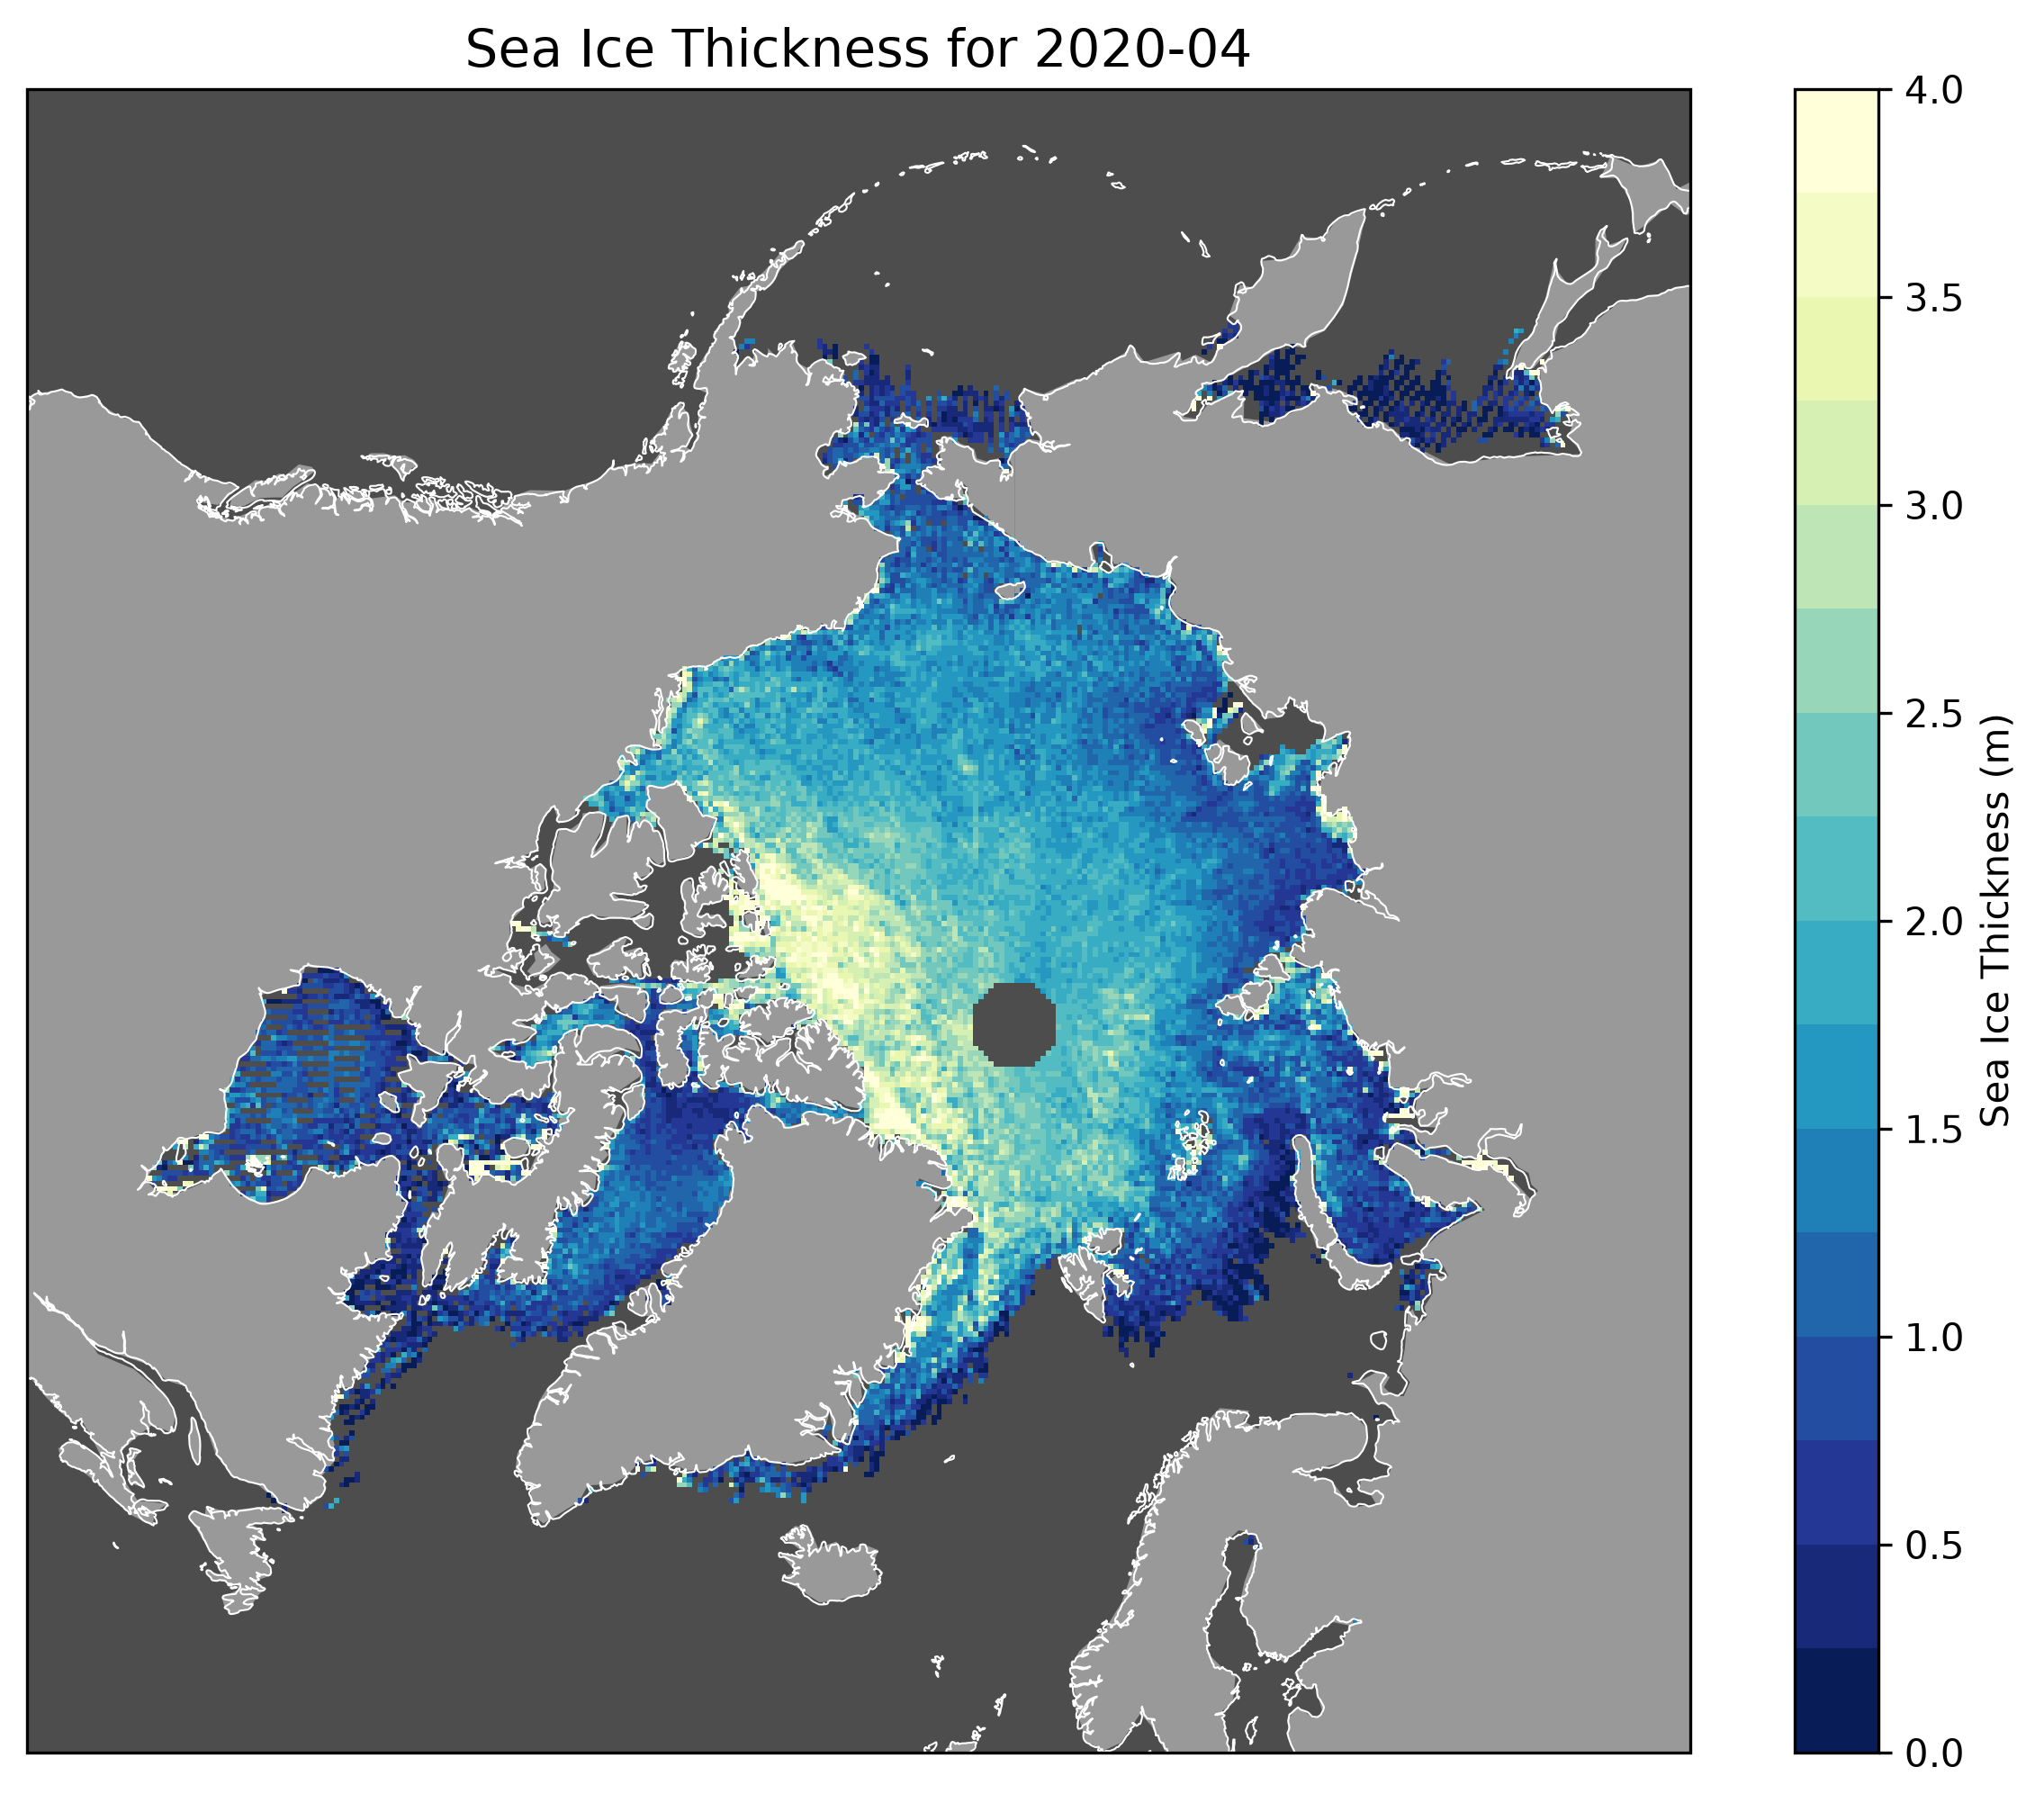

In [13]:
plot_sit_cdr_variable(ds_cdr_l3, parameter="sea_ice_thickness", target_month=target_month)

**Figure 1**. Map of Arctic sea ice thickness from CryoSat-2 data from all altimeter ground tracks within one month. The regional sea ice thickness distribution shows the expected pattern of thick multi-year sea ice in the western Arctic Ocean, especially north of Greenland and the Canadian Archipelago, and thinner sea ice in the Eastern Arctic and outside the central Arctic Ocean. 

#### Sea Ice Thickness Uncertainty

The netCDF variable name for the sea ice thickness uncertainty is simply `uncertainty`. It contains the algorithm uncertainty for the sea ice thickness value in each grid cell. In relative terms, the uncertainty is often a substantial fraction of the sea ice thickness itself. This is due to many contributing factors and their importance varies with time and regions. 

The main uncertainty contributions are:

**Uncertainty in the altimeter derived freeboard**
Sea ice and its snow cover are a complex medium with highly heterogenous radar backscatter properties with a variability at sub-meter scale. Contributing factors to the heterogenity are variations in sea ice surface height, the mixing of different sea ice types with strong variations in radar backscatter within a single radar altimeter footprint as well as a likely but unknown backscatter contribution from the snow layer. Backscatter from the snow surface or volume shifts the backscatter elevation distribution higher values, but strong localized backscatter targets such as thin ice areas may 'snag' the radar range to longer values and subsequently the freeboard to lower values. Due to the combinations of these competing effects, freeboard has large uncertainty, but a consistently positive bias due to snow backscatter must not be expected. 

**Use of climatologies for auxiliary information**
The freeboard to thickness conversion requires the knowledge of the mass of the overlying snow layer and the density of sea ice layer. Measurements of for both variables are not available for the full period of the climate data record and must be derived from climatologies. However, the sea ice thickness uncertainty is highly sensitive to errors in snow mass and sea ice density and the large spatial correlation length scale of these error prevent error reduction by gridding. 

The uncertainty algorithm takes all these error contributions and the random or systematic (spatial correlation length scale substantially larger then grid cells) into account. Not known are the covariances between the error contributions, which are not included by necessity in the uncertainty computation. 

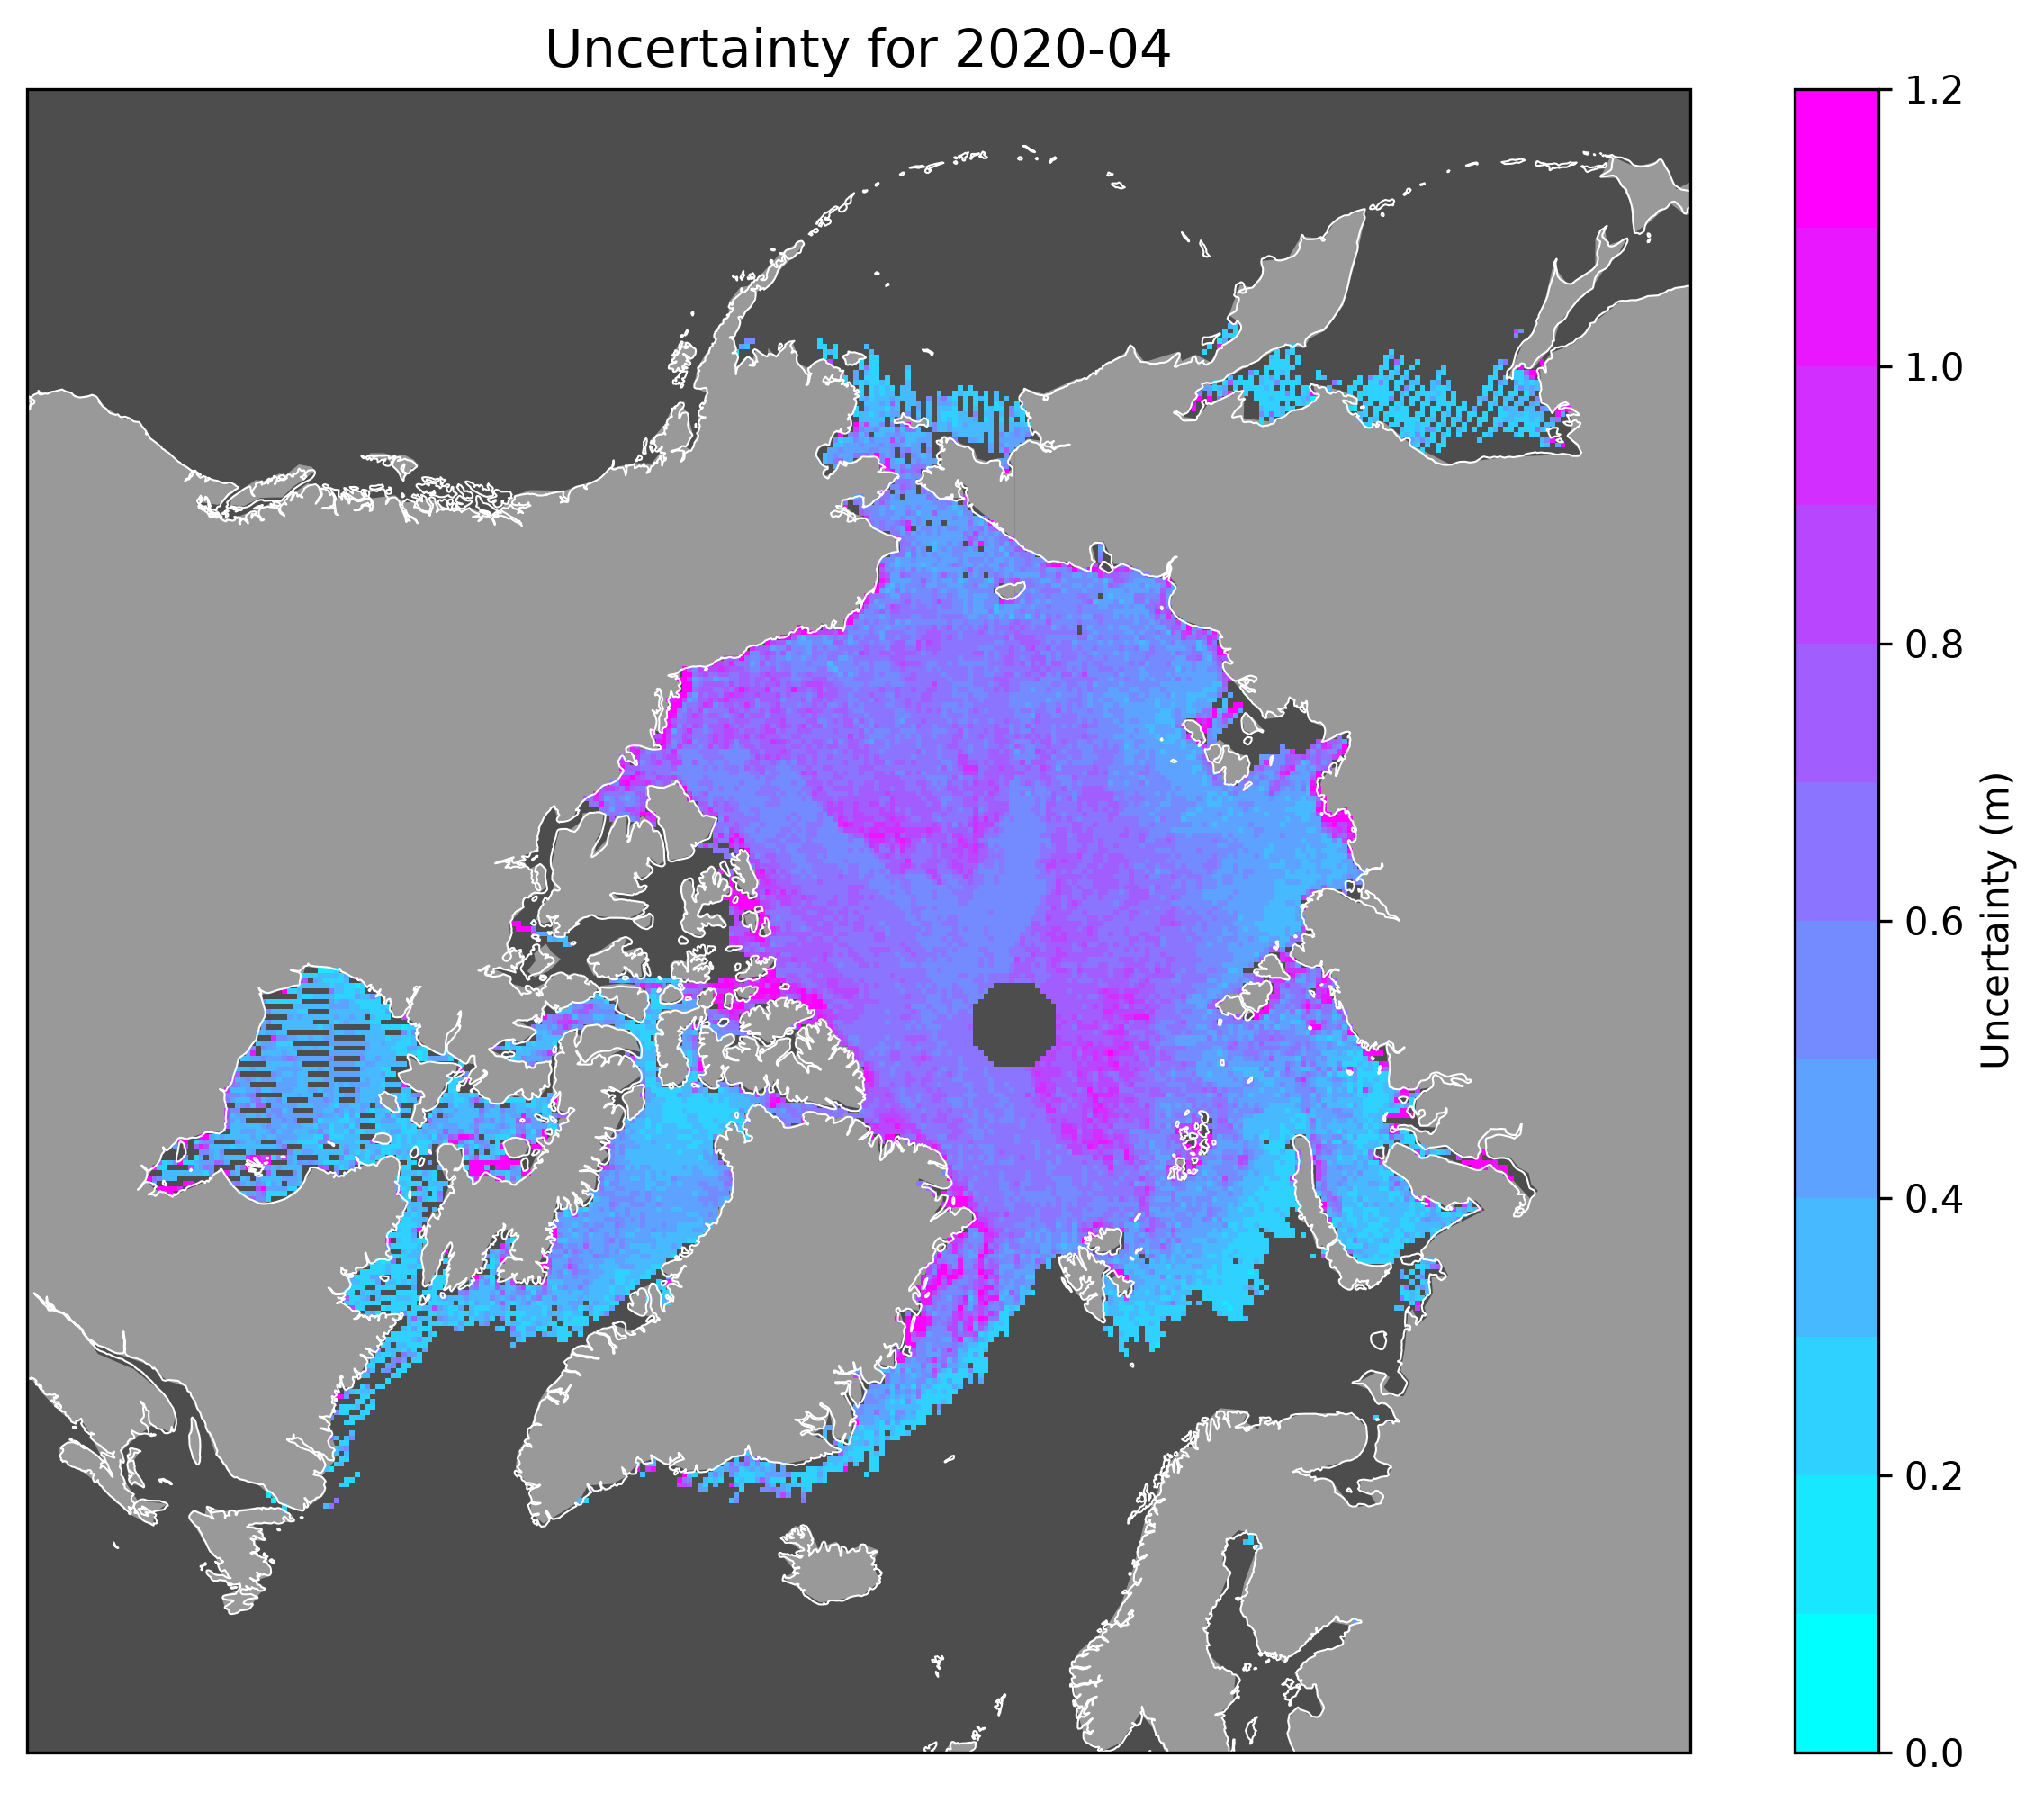

In [14]:
plot_sit_cdr_variable(ds_cdr_l3, parameter="uncertainty", target_month=target_month)

**Figure 2**. Map of Arctic sea ice thickness uncertainty for the month April 2020. In some areas the sea ice thickness uncertainty can reach values of more than 1 meter due the substantial error budget of the sea ice thickness retrieval algorithm. 

### Flags

In addition to the variables, to flag variables provide information on the status and the quality of the sea ice thickness retrieval. 

#### Status Flag

The status flag merges information on data coverage, success of the sea ice thickness retrieval and general surface type (land, open ocean or sea ice). The flag stores values from 0 to 5 and the values and meanings of the flag can be obtained by the `flag_values` and `flag_meaning` attributes of the `status_flag` variable.

0. **Nominal Retrieval**: Sea ice thickness retrieval successful (surface type: sea ice)
1. **No Data**: No altimeter data coverage (surface type: either sea ice or ocean)
2. **Open Ocean**: surface type: ocean
3. **Satellite Pole Hole**: North of satellite data coverage (> 88N for CryoSat-2 and > 81.5N for Envisat)
4. **Land, Lake or Land Ice**: Not in the marine domain, do not expect data
5. **Retrieval failed**: Sea ice thickness retrieval failed (surface type: sea ice)


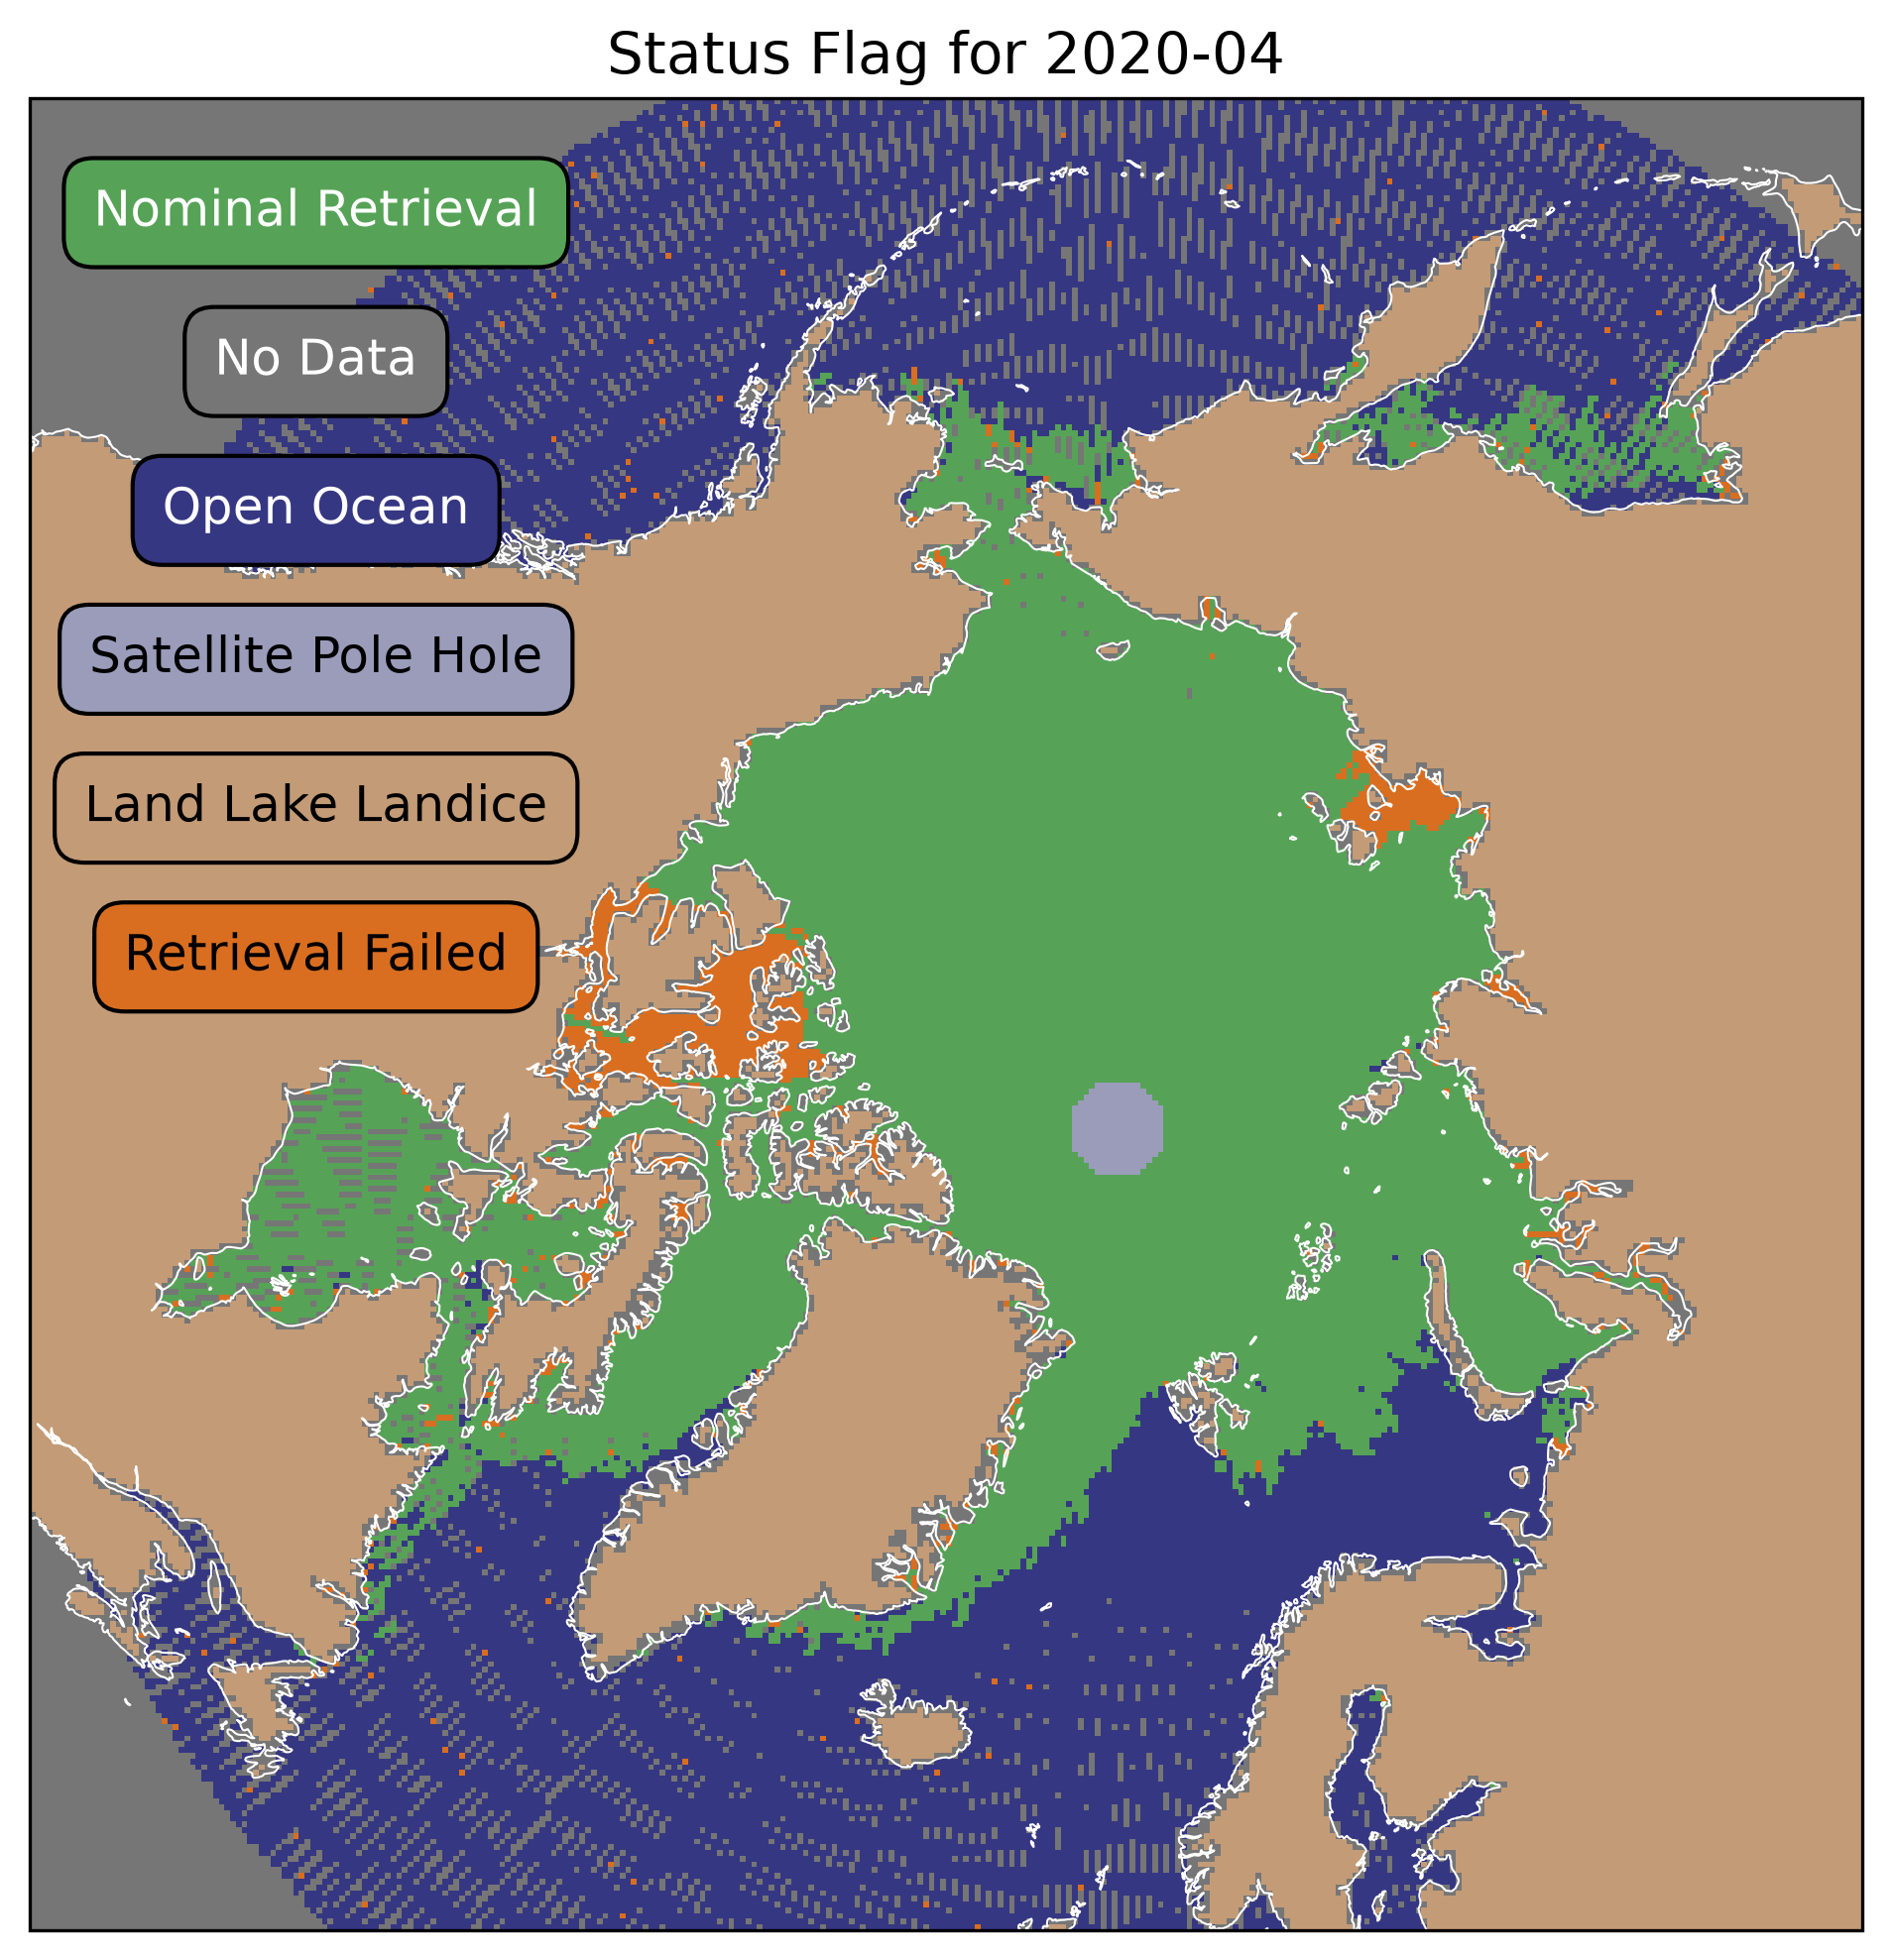

In [15]:
plot_sit_cdr_flag(ds_cdr_l3, parameter="status_flag", target_month=target_month)


**Figure 3** Status flag of the sea ice thickness climate data record for April 2020. The color coding indicates the flag value and the flag meanings are annotated in colored boxes at the upper left part of the map. 

#### Quality Flag

The quality flag provides and expert assessment of the sea ice thickness quality. The determination of the flag value is based on a set of criteria, which are described in the Algorithm Theoretical Basis Document, which can be accessed in the [documentation tab](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-thickness?tab=documentation) of the CDS dataset page. The flag stores values from 0 to 4 and the values and meanings of the flag can be obtained by the `flag_values` and `flag_meaning` attributes of the `status_flag` variable.

0. **Nominal quality** Retrieval is reliable and has sufficient data coverage
1. **Intermediate Quality**: Certain factors decrease reliability, but data may still be used in most cases
2. **Low Quality**: Problematic retrieval parameters or very low number of data points within grid cell. Use with care.
3. **No Data**: No sea ice thickness values

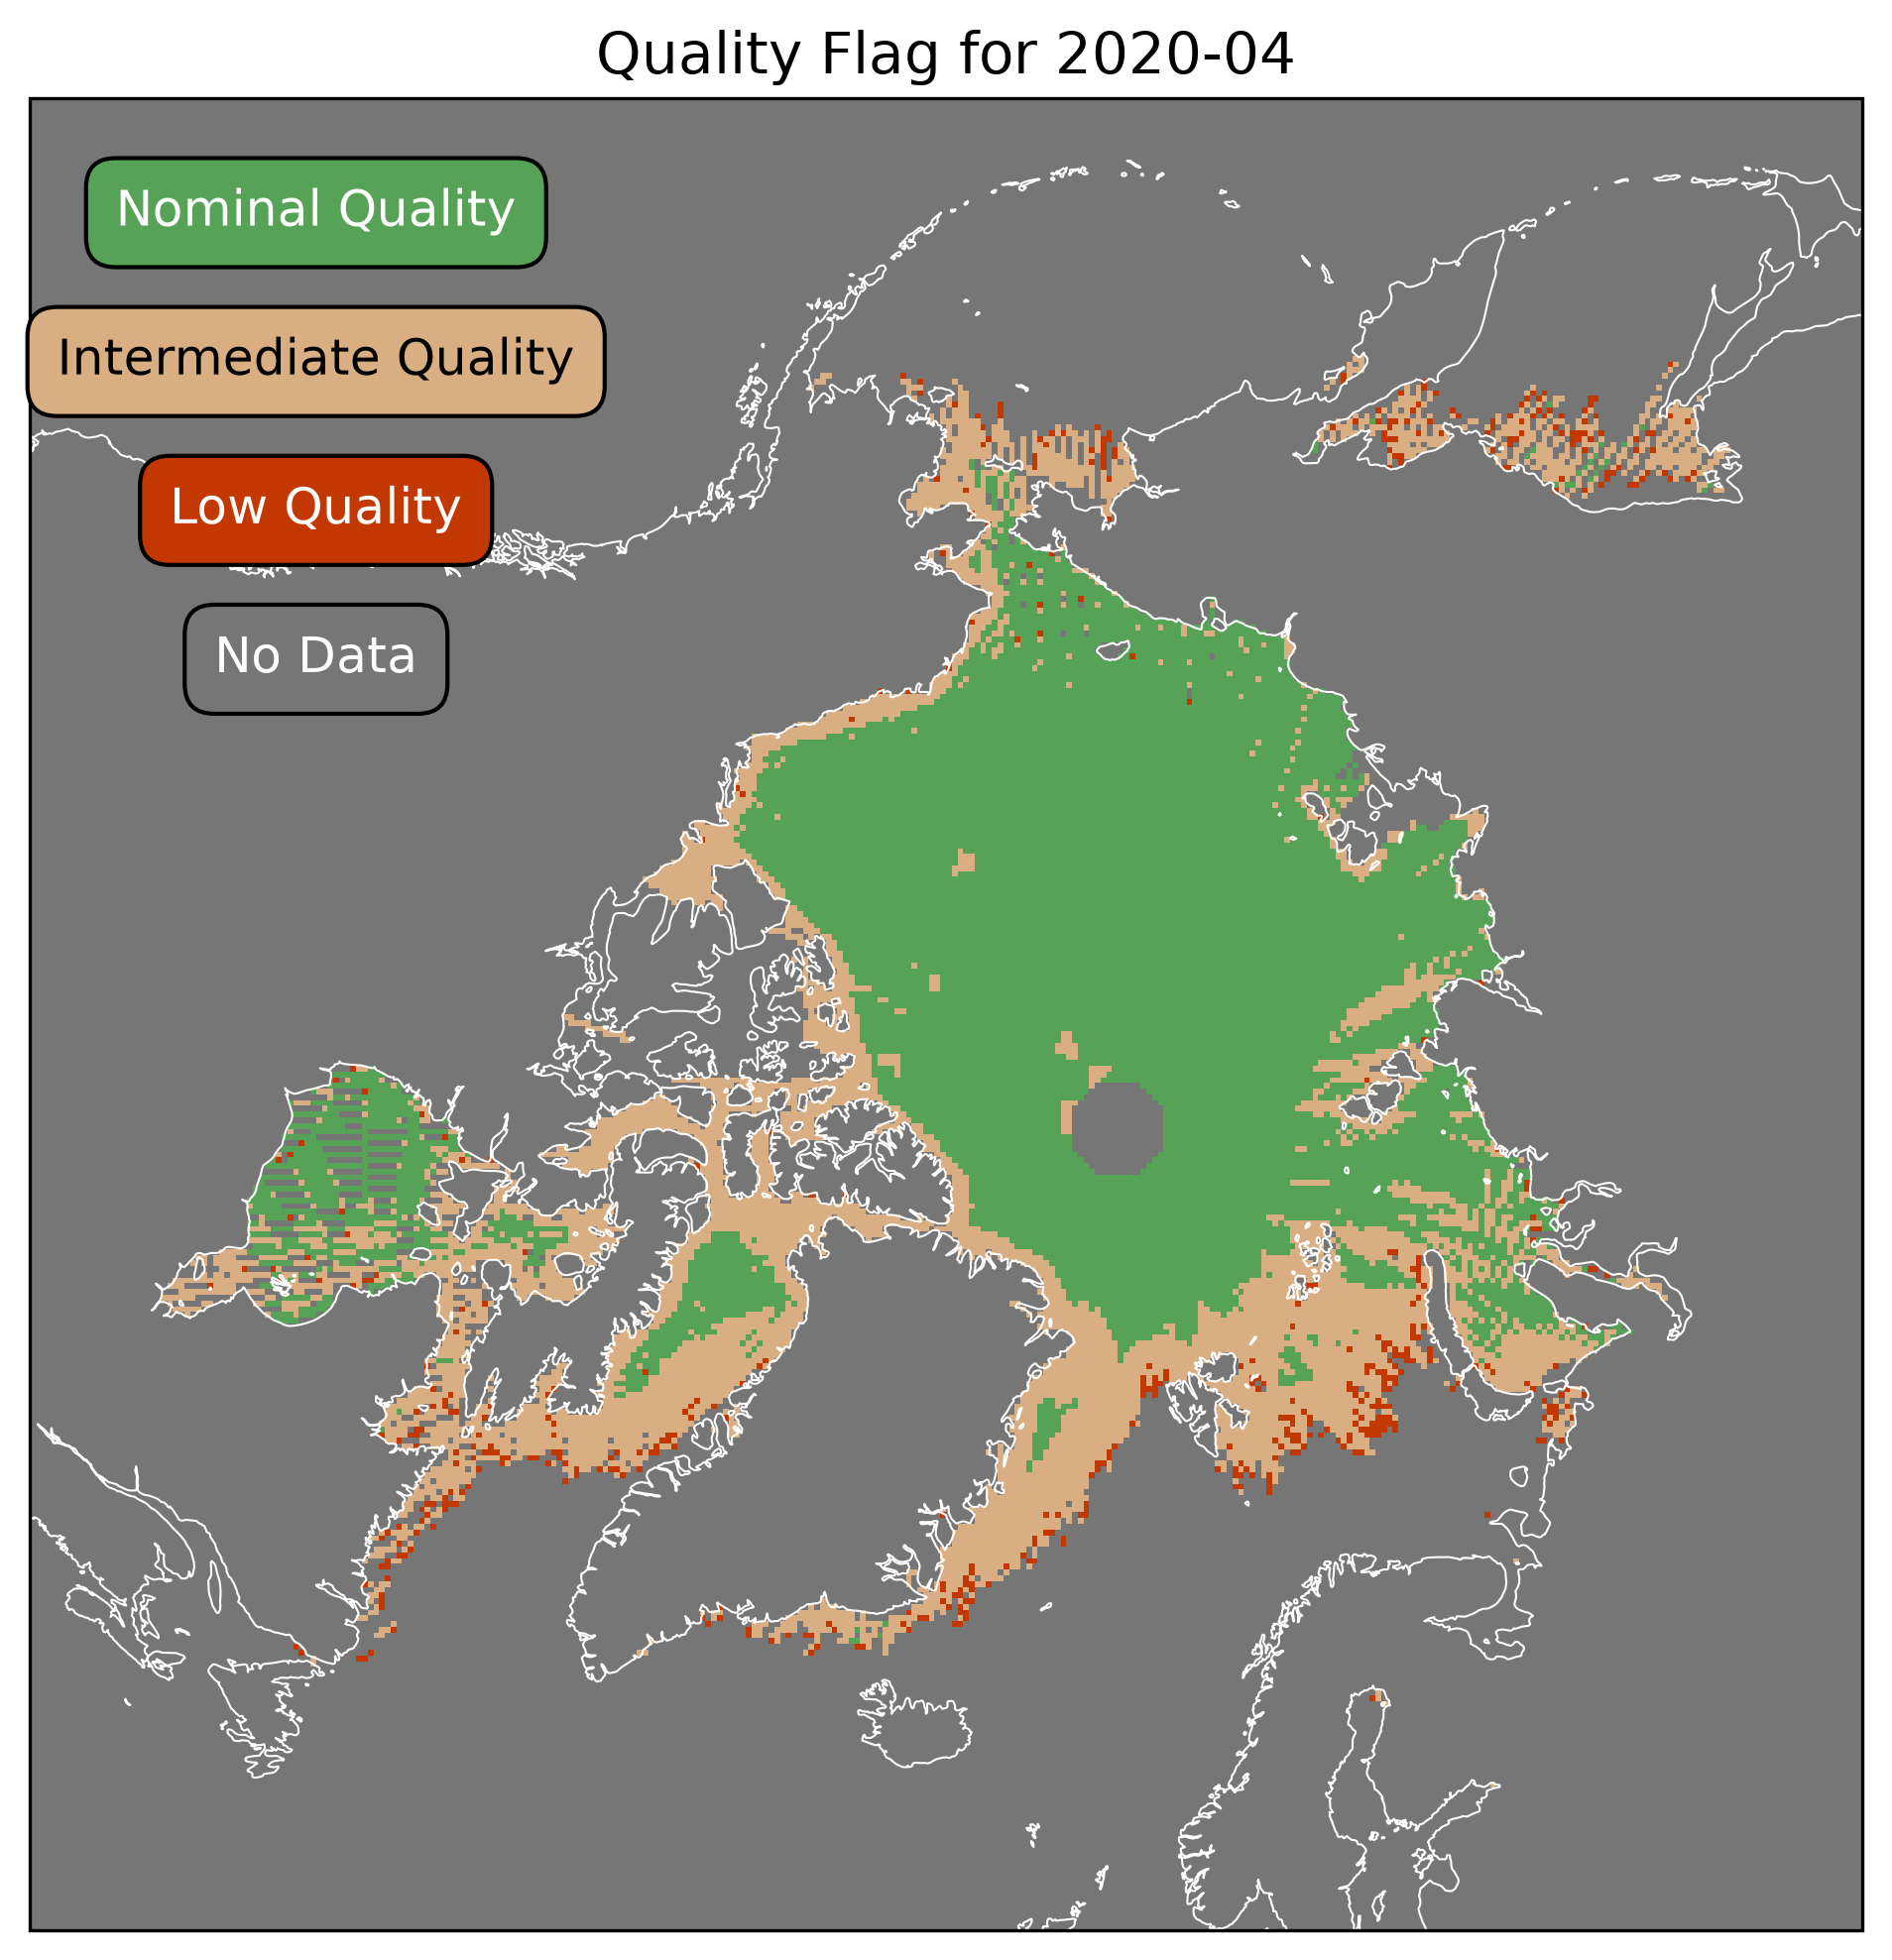

In [16]:
plot_sit_cdr_flag(ds_cdr_l3, parameter="quality_flag", target_month=target_month)

**Figure 4** Quality flag of the sea ice thickness climate data record for April 2020. The color coding indicates the flag value and the flag meanings are annotated in colored boxes at the upper left part of the map. 

## Differences between Climate Data Record and CryoSat-2/SMOS sea ice thickness

The main focus of this tutorial is on the sea ice thickness climate data record. However, the combined CryoSat-2/SMOS sea ice thickness data record is available in the same download mask and we shortly evaluate and visualize the difference between the two datasets. 

#### Resample Daily Combined CryoSat-2/SMOS sea ice thickness to monthly temporal resolution

Both datasets are provided at the different temporal resolution. The combined CryoSat-2/SMOS product is provided with a daily resolution and we create a monthly average based on the already downloaded data using the `resample` function for `xarray` datasets: 

In [17]:
ds_l4_monthly = ds_cs2smos_l4.resample(time="1ME").mean()

The CryoSat-2/SMOS data now contains a monthly field for March 2024. Please note that we choose March here, because for this month the CryoSat-2/SMOS data record has a full data coverage as the data record only includes the second half of October and the first half of April. By choosing March, we ensure that we compare the same period. 

In the next step we extract the same months from the sea ice thickness climate data record. We also use `xarray` function to select the time. Please note that the time value for each month in the climate data records points the first day of the month. 

In [18]:
ds_l3_subset = ds_cdr_l3.sel(time=["2024-03-01"])

### Plotting routines

In the next step we create a plotting routine, which create a figure with four panels showing the gridded sea ice thickness values of the two dataset as well as the thickness difference as a map and as a histogram. 

In [19]:
def plot_compare_sit_l3_l4(
        ds_l3: xr.Dataset,
        ds_l4: xr.Dataset
) -> None:
    """
    Plot the sea ice thickness for a given dataset.
    """

    # Extract the monthly sea ice thickness
    sit_l3 = ds_l3["sea_ice_thickness"].isel(time=[0]).squeeze()
    sit_l4 = ds_l4["sea_ice_thickness"].isel(time=[0]).squeeze()

    # Extract coordinates and convert from km to meters (see output above, where x and y range go from -5387 to + 5387)
    x = ds_l3["xc"].values * 1000  # converting km to m
    y = ds_l3["yc"].values * 1000

    fig = plt.figure(figsize=(12, 12))
    specs = fig.add_gridspec(ncols=2, nrows=2)

    grid_variables = [sit_l3, sit_l4, sit_l4 - sit_l3]

    colormesh_kwarg_list = [COLORMESH_KWARGS_DICT["sea_ice_thickness"]] * 2
    colormesh_kwarg_list += [COLORMESH_KWARGS_DICT["sea_ice_thickness_difference"]]
    titles = ["CryoSat-2 (CDR)", "CryoSat-2/SMOS", "CryoSat-2/SMOS - CryoSat-2 (CDR)"]
    cbar_labels = ["Sea Ice Thickness (m)"] * 2 + ["Sea Ice Thickness Difference (m)"]

    for i in range(3):

        # Only plot
        col_idx = i % 2
        row_idx = i // 2
        ax = plt.subplot(specs[row_idx, col_idx], projection=PLOT_PROJECTION)
        add_grid_variable_to_axes(
            ax, fig, x, y, grid_variables[i],
            colormesh_kwargs=colormesh_kwarg_list[i],
            axes_title=titles[i],
            colorbar_label=cbar_labels[i]
        )

    # Last panel sea ice thickness difference histrogram
    ax = plt.subplot(specs[1, 1])

    # Plot the histogram
    sit_diffs = (sit_l4 - sit_l3).values.flatten()
    sit_diffs = sit_diffs[~np.isnan(sit_diffs)]
    bin_edges = np.arange(-1.2, 1.21, 0.02)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    ax.hist(sit_diffs, bins=bin_edges, histtype="step", color="#4b4b4d", linewidth=0.75, zorder=200)
    n, bins, patches = ax.hist(sit_diffs, bins=bin_edges, zorder=180)
    vmin, vmax = colormesh_kwarg_list[-1]["vmin"], colormesh_kwarg_list[-1]["vmax"]
    color_index = np.array((bin_centers - vmin) / (vmax - vmin))
    color_index = np.clip(color_index, 0, 1)
    for c, p in zip(color_index, patches):
        plt.setp(p, 'facecolor', cmaps.rdbu_8(c))

    # Add the mean sea ice thickness difference
    mean_sit_diff = np.nanmean(sit_diffs)
    ax.axvline(0.0, color="#000000", linewidth=0.75, zorder=300)
    ax.axvline(mean_sit_diff, 0, 0.9, linestyle="--", color="#67001f", linewidth=1, zorder=300)
    ax.text(mean_sit_diff-0.05, ax.get_ylim()[1] * 0.9, f"Mean SIT Difference:\n{mean_sit_diff:.2f} m",
            ha="right", va="top", color="#67001f", zorder=300)

    # Style the axes
    ax.set_xlabel("Sea Ice Thickness Difference (m)")
    ax.set_yticks([])
    for target in ["top", "left", "right"]:
        ax.spines[target].set_visible(False)
    ax.set_xlim(-1.1, 1.1)
    ax.set_xticks(np.linspace(-1., 1., 9))

    plt.show()


### Sea Ice Thickness Difference

Now we plot the diffences of the climate data record subset and the monthly aggregated combined product. The result is shown below in Figure 5. 

Due to the use of the optimal interpolation, the combined product is smoother compared to the climate data record and in additions free of gaps. The regional distribution of sea ice thickness values remains consistent, even in the thin ice areas. The sea ice thickness difference map therefore appears noisy, but shows consistently thinner ice in areas close to open ocean as well as in Baffin Bay. This is caused by the heightened impact of the SMOS thin ice observations in these areas. 

On average, the combined sea ice thickness products is approximately 0.1 m or 7% thinner at an average northern hemisphere sea ice thickness of 1.4 m. 

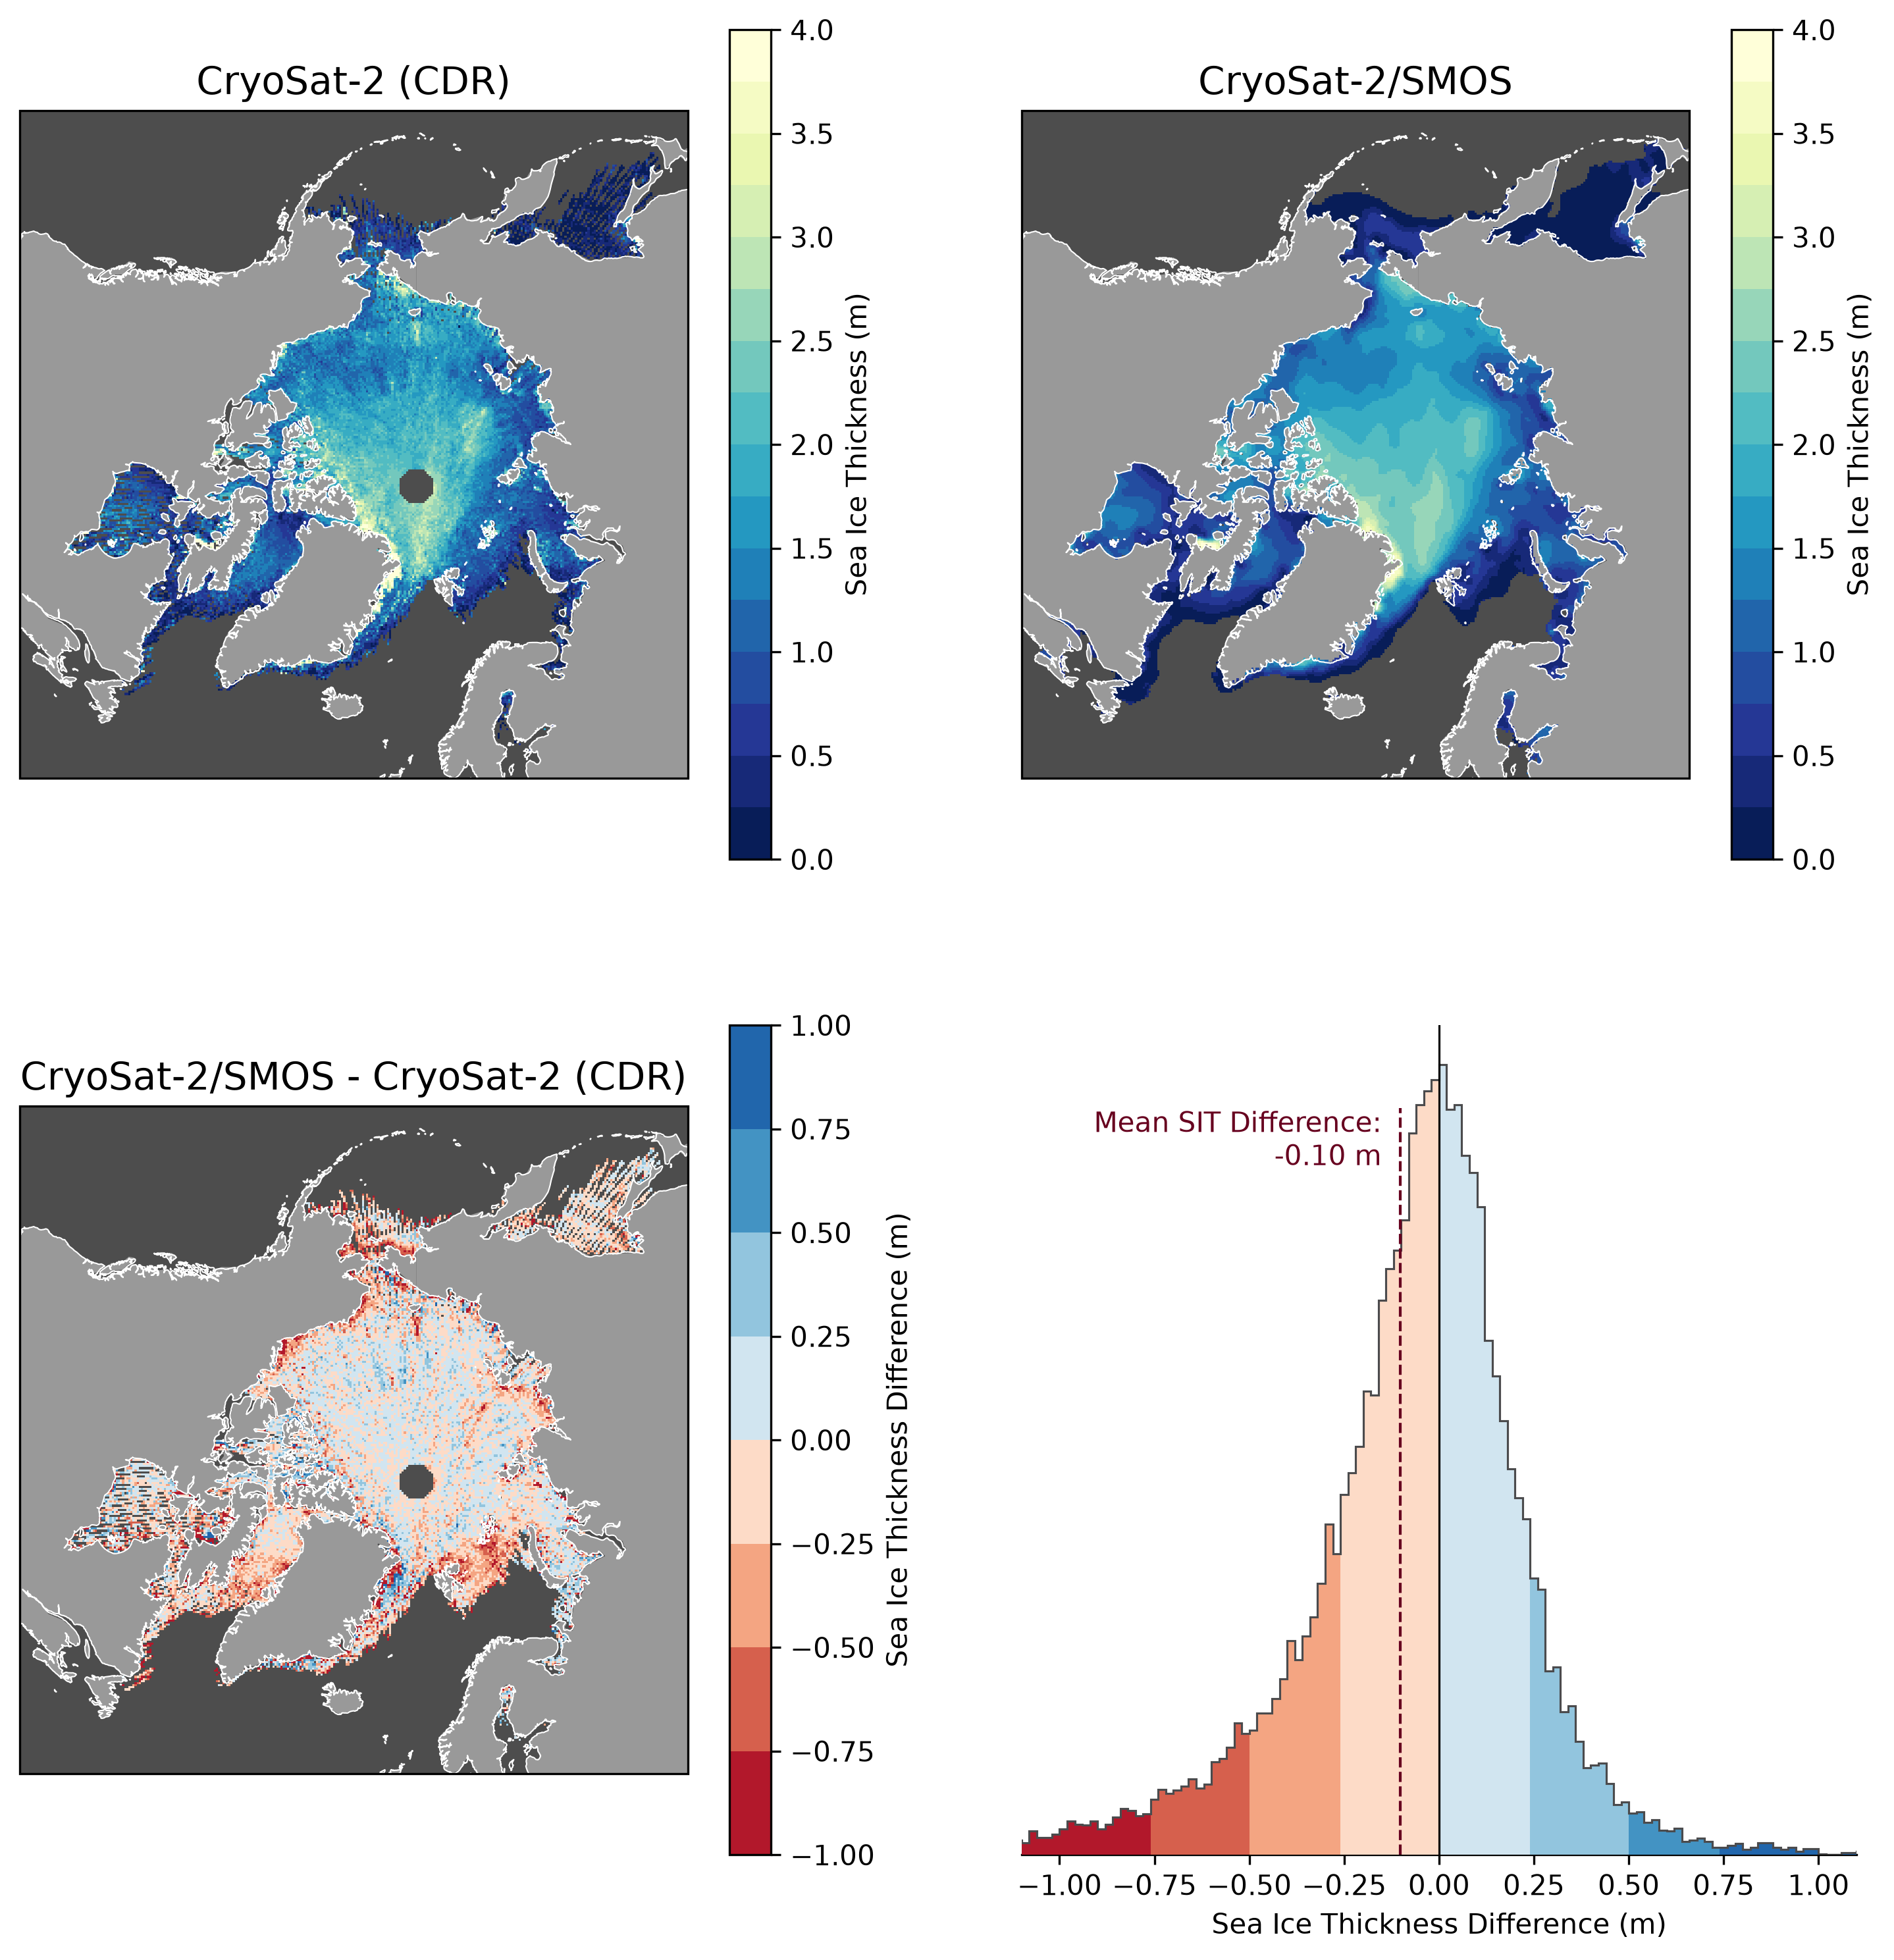

In [20]:
plot_compare_sit_l3_l4(ds_l3_subset, ds_l4_monthly)

**Figure 5**: Comparison of two sea ice thickness datasets of the climate data record based on CryoSat-2 and the combined CryoSat-2/SMOS dataset from March 2024. (*Top Left*): Sea ice thickness from climate data record, (*Top Right*): Sea ice thickness from combined CryoSat-2/SMOS data record, averaged over all daily files within March, (*Lower Left*) Sea ice thickness difference map (Combined product minus climate data record), and (*Lower Right*) Sea ice thickness difference histogram (Combined product minus climate data record)

## Compute Arctic Sea Ice Thickness Variability and Change in April  

In the last step of this tutorial we will use the sea ice thickness climate data record to evaluate sea ice thickness trends and compute their significance for all April values between 2011 and 2024. We choose this time period due to the availiability of CryoSat-2 data with its better geograpical coverage. 

The analysis can be extend to Envisat data, but in this case the trend analysis is limited to a latitude range south of 81.5N excluding a substantial part of the central Arctic Ocean.

### Setup data and computation

First, we prepare the data and create the function to compute the analysis variables. 

#### Extract all April Sea Ice Thickness fields observed by CryoSat-2

We use again `xarray` functionality to create a another subset of the climate data record: All April month since 2011. The resulting subset is then fed into functions to compute the analysis variables. 

In [21]:
# Extract the CryoSat-2 period from the climate data record (CDR) dataset
ds_cs2_l3 = ds_cdr_l3.sel(time=slice("2011-01-01", "2024-04-30"))

# Now extract only the April months from the CryoSat-2 period
ds_cs2_april = ds_cs2_l3.sel(time=ds_cs2_l3["time.month"] == 4)


#### Compute sea ice thickness variability

We define the variability of sea ice thickness as the sea ice thickness difference betwenn the 5th and 95th percentile of the sea ice thickness distribution per grid cell. This can be efficiently computed by using `xarray` functionality: 

In [22]:
def compute_sit_variability(
        ds: xr.Dataset,
        start_percentile: float = 0.05,
        end_percentile: float = 0.95
) -> xr.DataArray:
    """
    Compute the variability of the sea ice thickness by calculating 
    the difference between the 95th and 5th percentiles (default)
    across the time dimension. The percentiles can be adjusted by providing 
    different values for `start_percentile` and `end_percentile`.

    :param ds: xarray Dataset containing the sea ice thickness data
    :param start_percentile: The lower percentile to compute (default is 0.05)
    :param end_percentile: The upper percentile to compute (default is 0.95)

    :returns: Variability of the sea ice thickness
    """
    sit_p_start = ds["sea_ice_thickness"].quantile(start_percentile, dim=('time'))
    sit_p_end = ds["sea_ice_thickness"].quantile(end_percentile, dim=('time'))
    return sit_p_end - sit_p_start

#### Compute regional sea ice thickness trends and their 

Computing regional sea ice thickness trends requires fitting a linear model for each grid cell. Here, we not use `xarray`, but rely on `scipy.stats.lingress` for the estimation of the linear model. 

The implementation using two functions, one for selecting only appropriate grid cell with at least 10 sea ice thickness observations (`get_regional_sit_trends`) and another for computing the trend per grid cell, the p-value and if the trend is significant (p-value < 0.05). 

In [24]:
def compute_sit_trend(
        sits: np.ndarray,
        p_threshold: float = 0.05
):
    """
    Compute the trend and its significance.


    :param sits: Array of sea ice thickness values
    :param p_threshold: The p-value for the significance criterion

    :returns: slope, p-value, p-value < p-threshold
    """
    x = np.arange(sits.shape[0])
    is_valid = np.isfinite(sits)
    linfit = linregress(x[is_valid], sits[is_valid])

    return linfit.slope, linfit.pvalue, linfit.pvalue < p_threshold


def get_regional_sit_trends(
        ds: xr.Dataset,
        n_min_sit_obs: int = 10
):

    dims = [ds.sizes["yc"], ds.sizes["xc"]]

    # Init the output arrays
    sit_trend = np.full(dims, np.nan)
    sit_trend_p_value = np.full(dims, np.nan)
    sit_trend_significant = np.full(dims, False)

    finite_obs_count = ds["sea_ice_thickness"].count(dim="time")
    has_enough_sit_obs = finite_obs_count >= n_min_sit_obs

    # Get list of grid cell for which to compute the SIT trend
    idx = np.where(has_enough_sit_obs)
    sit = ds["sea_ice_thickness"].values
    for ix, iy in zip(idx[0], idx[1]):
        trend, p_value, is_significant = compute_sit_trend(sit[:, ix, iy])
        sit_trend[ix, iy] = trend
        sit_trend_p_value[ix, iy] = p_value
        sit_trend_significant[ix, iy] = is_significant

    return sit_trend, sit_trend_p_value, sit_trend_significant

#### Plotting 

In the last step we create a plotting function, which generates a four panel figure with the average April sea ice thickness, the thickness variability in April as well as the trend in meters/decade and the trend p-value with. 

In [25]:
def plot_cryosat2_sit_trends(ds: xr.Dataset) -> None:
    """
    Plot the sea ice thickness for a given dataset.
    """

    # Compute the April average sea ice thickness
    sit_mean = ds["sea_ice_thickness"].mean(dim="time")

    # Compute the variability defined as the difference between the 95th and 5th percentiles
    # of the sea ice thickness distribution per grid cell
    sit_var = compute_sit_variability(ds)

    # Compute the sea ice thickness trend per grid cell
    # (Only for grid cells with at least 10 observations
    sit_trend, sit_trend_p_value, sit_trend_significant = get_regional_sit_trends(
        ds,
        n_min_sit_obs=10
    )
    sit_trend *= 10  # From m/year to m/decade

    # Extract coordinates and convert from km to meters (see output above, where x and y range go from -5387 to + 5387)
    x = ds["xc"].values * 1000  # converting km to m
    y = ds["yc"].values * 1000

    fig = plt.figure(figsize=(12, 12))
    specs = fig.add_gridspec(ncols=2, nrows=2)
    grid_variables = [sit_mean, sit_var, sit_trend, sit_trend_significant]

    colormesh_kwarg_list = [
        COLORMESH_KWARGS_DICT["sea_ice_thickness"],
        COLORMESH_KWARGS_DICT["sea_ice_thickness_variability"],
        COLORMESH_KWARGS_DICT["sea_ice_thickness_trend"],
        COLORMESH_KWARGS_DICT["sea_ice_thickness_significance"]
    ]
    titles = ["Mean April Thickness", "Variability", "Linear Trend", "Significance"]
    cbar_labels = ["Sea Ice Thickness (m)"] * 2 + ["Sea Ice Thickness Trend (m/decade)", "Trend Significance (p < 0.05)"] 

    for i in range(4):

        # Only plot
        col_idx = i % 2
        row_idx = i // 2
        ax = plt.subplot(specs[row_idx, col_idx], projection=PLOT_PROJECTION)
        add_grid_variable_to_axes(
            ax, fig, x, y, grid_variables[i], colormesh_kwargs=colormesh_kwarg_list[i],
            axes_title=titles[i], colorbar_label=cbar_labels[i]
        )
    plt.show()

### Sea Ice Thickness Variability and Trends in April from 2010 to 2024

Now we can compute the sea ice thickness variability and trends. Figure 6 below shows the mean thickness field, the variability, trend and the trend significance flag. 

The analysis indicates that the regions with the most variability are the band of thick multi-year sea ice north of the Canadian Archipelago as well as the near-coastal regions with presumably variabils land-fast ice coverage. The overall sea ice thickness trends is mostly negative with values reaching -1 meter / decade in the thick multi-year sea ice north of the Canadian Archipelago. A spatially extensive regions with slightly positive sea ice thickness trends is visible in the Eastern Arctic Ocean though. However, few of the grid cells exhibit trends that are statistically significant and the scattered distribution of those who do indicate that random noise may be a contributing factor to the positive significance flag. 



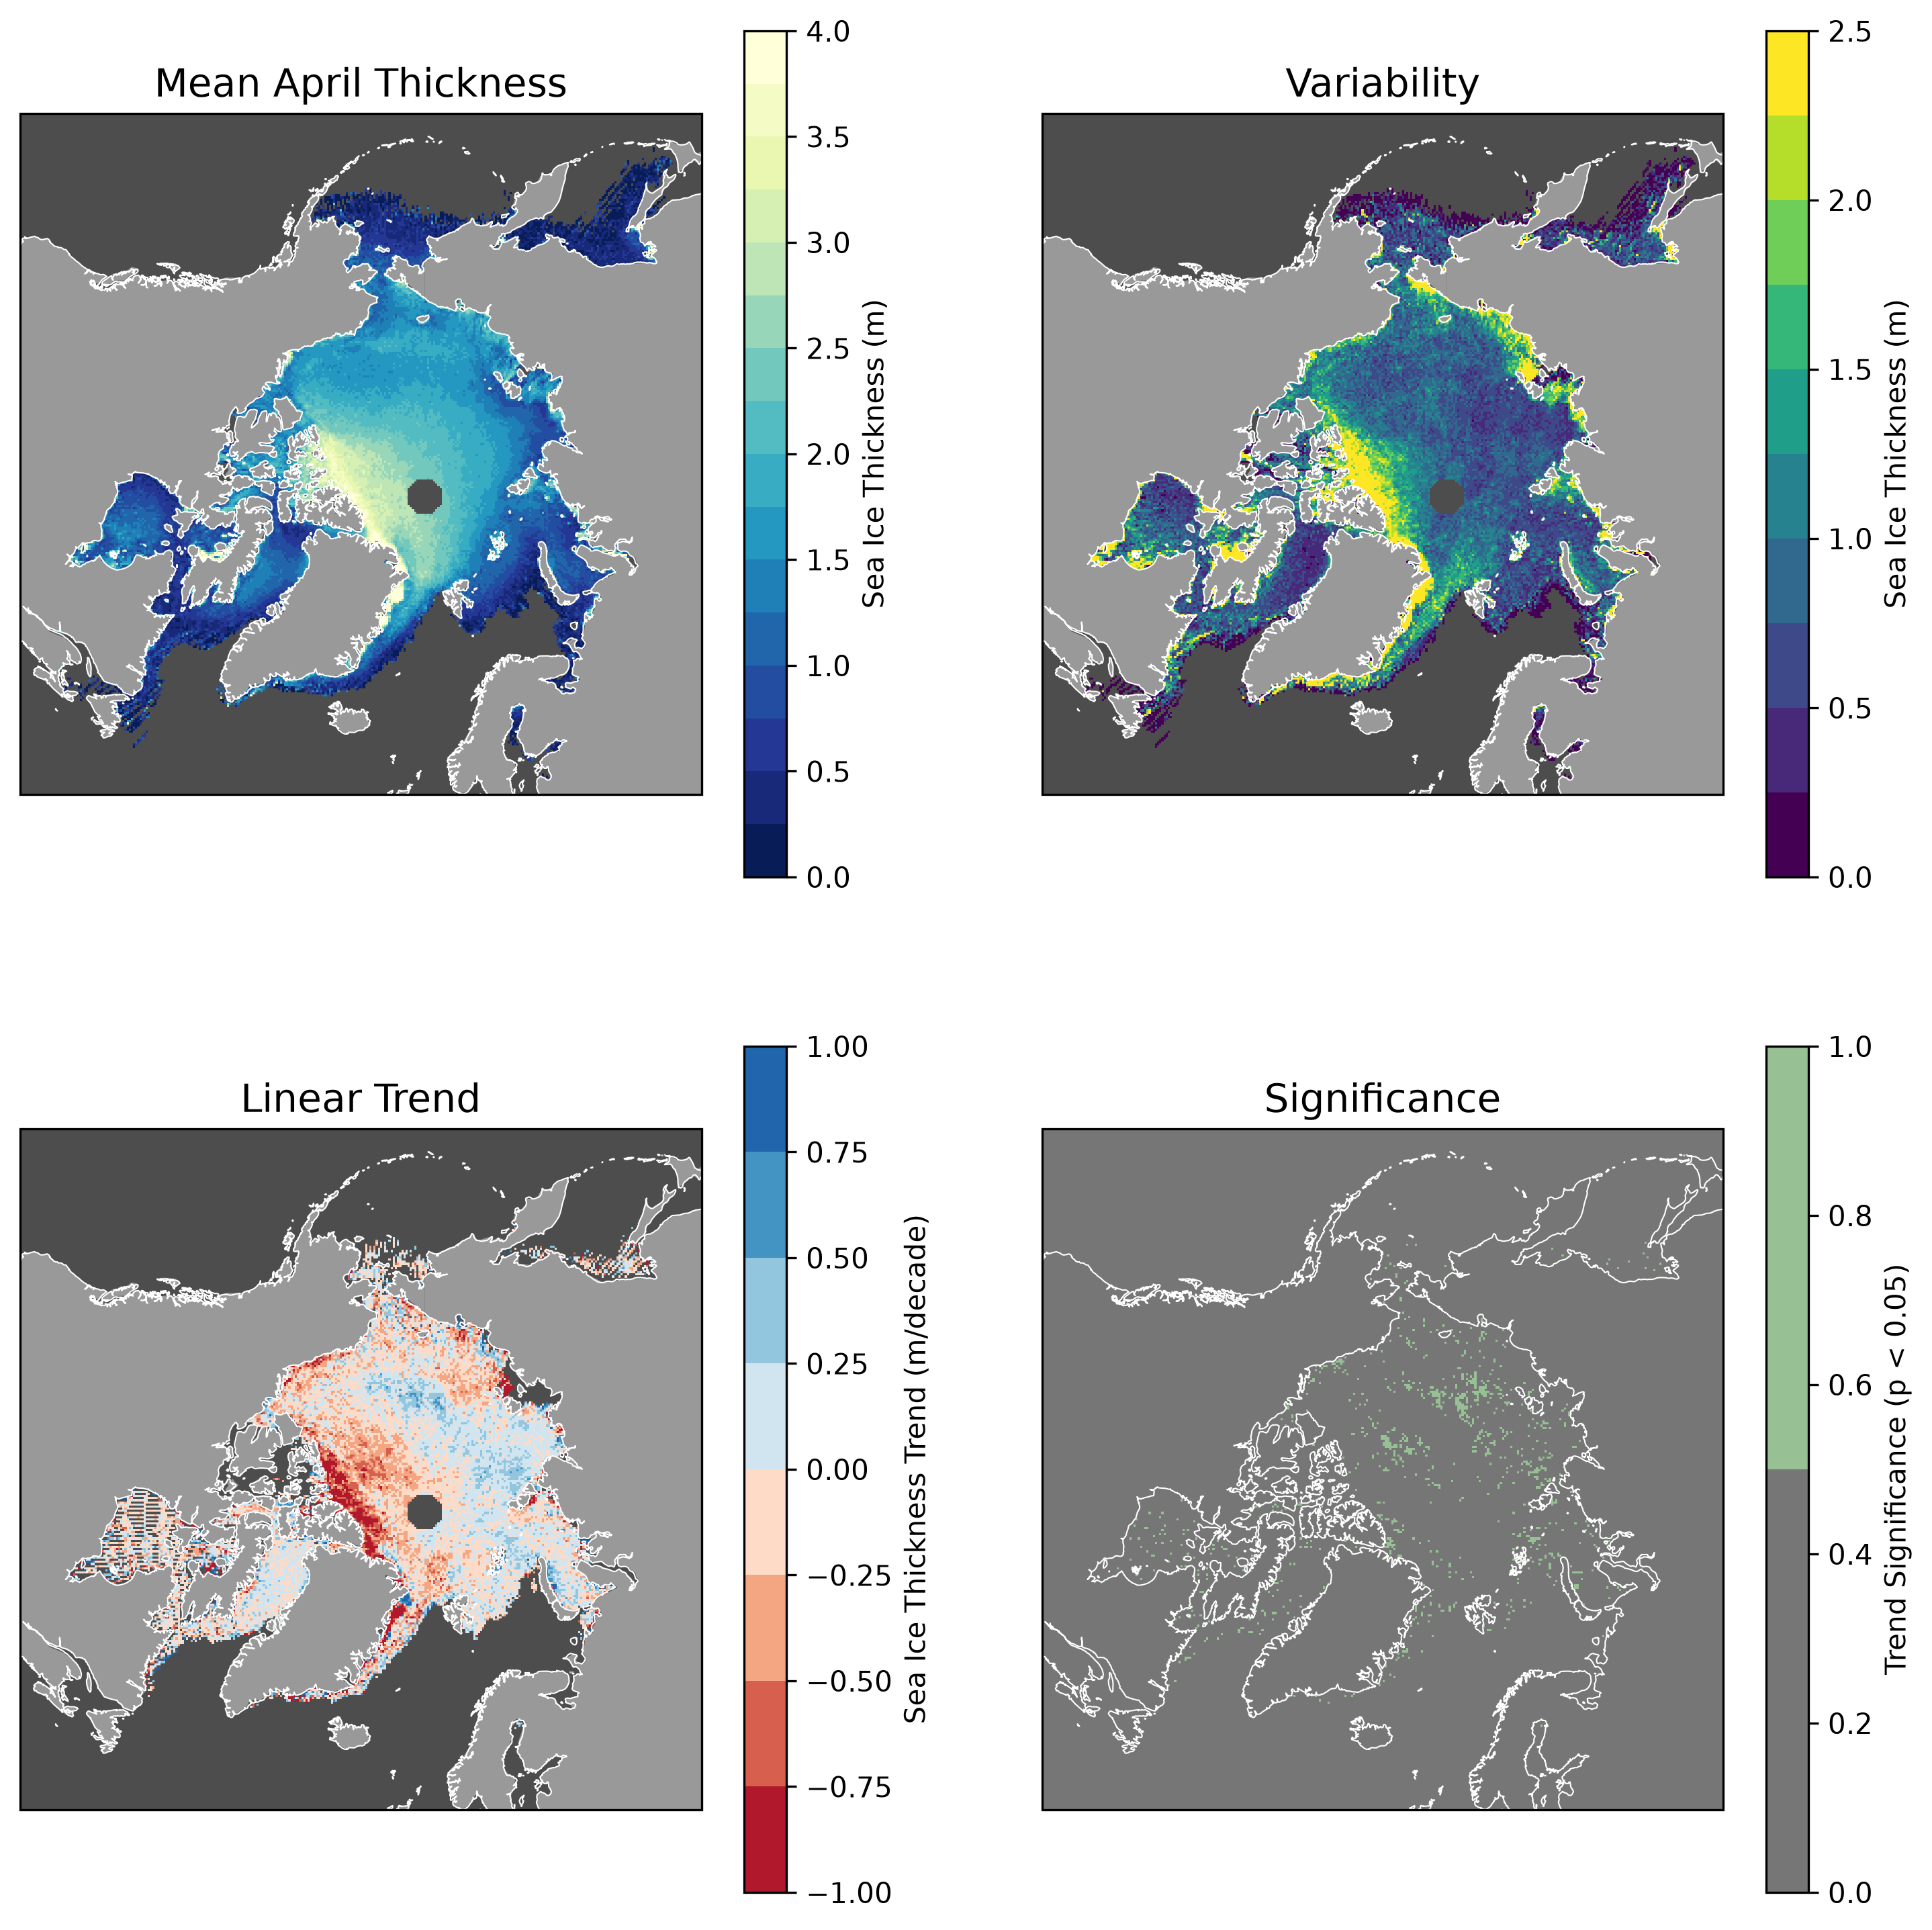

In [26]:
plot_cryosat2_sit_trends(ds_cs2_april)

**Figure 6**: Metrics for sea ice thickness variability and change for all months of April between 2011 and 2024. (*Top Left*): Mean April sea ice thickness from CryoSat-2 data in the climate data records (*Top Right*): April sea ice thickness variability computed from the 5th and 95th percentiles (*Lower Left*) sea ice thickness trend in meters per decade derived from linear model for grid cells with at least 10 months of data coverage (*Lower Right*) Trend significance (p-value < 0.05) of the linear model with lighter green colors indicating grid cells where the trend is significant. 


## Take home messages 📌

In this notebook, we evaluated both available sea ice thickness data from the Climate Data Store and illustrated how the 

- The [Climate Data Store](https://cds.climate.copernicus.eu/) contains two different of sea ice thickness datasets that differ in temporal coverage and resolution as well as in source data and methodology. 
- The climate data record has a variable geographical coverage over time but a longer time series, while the combined CryoSat-2/SMOS data record provides gapless sea ice thickness since 2010.
- The combined CryoSat-2/SMOS data is thinner on average due to the inclusion of SMOS thin ice thickness data and smoother due to the underlying optimal interpolation method. 
- Sea ice thickness trends since 2010 at the end of the winter are not stastically significant, but the show a regionally consistent pattern with thinning in the multi-year ice area north of the Canadian Archipelago and a thickening in the Eastern part of the central Arctic Ocean. 